# `SurfTrack`
## Tracking and Measures
SurfTrack operates on 3-D data `(time, lat, lon)` and uses:
1. Morphological close→open to clean the binary field
2. Area filtering to remove small noise objects
3. 3-D connected-component labelling across time and space
4. Date-line wrapping for global datasets

For subsurface (4-D) tracking see the **DeepTrack** tutorial.

### 1. Imports

In [1]:
import sys
import os

# Go up from notebooks/ to repo root
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, repo_root)

In [2]:
from ocetrac.SurfTrack import SurfTracker
from ocetrac.preprocessing.cesm2_lens_utils import get_ds_var
from ocetrac.preprocessing.preprocessing import calculate_anomalies_trend_features

In [9]:
import numpy as np
import xarray as xr

import cmocean
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter,LatitudeFormatter
from cartopy.util import add_cyclic_point
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import matplotlib.dates as mdates

import warnings

warnings.filterwarnings("ignore", message=".*decode the variable.*")
warnings.filterwarnings("ignore", message=".*default value for data_vars.*")

### 2. Data loading

This section loads CESM2 Large Ensemble (CESM2-LENS) SST data for a single ensemble member. The CESM2-LE provides 100 ensemble members spanning 1850-2100.
- Component: `atm` (atmosphere model component)
- Temporal resolution: Monthly means

In [16]:
%%time

ens_memb_index = 0
var, comp  = 'SST', 'atm'
directory  = f'/glade/campaign/cgd/cesm/CESM2-LE/{comp}/proc/tseries/month_1/{var}/'

ds_hist, _ = get_ds_var(directory, var, comp, ens_memb_index)

nlat_low, nlat_high = 26, 328
da_sst = ds_hist[var].sel(
    lat=slice(-65, 65),
    time=slice('1979-01', '2015-01')).compute()

print(f"Loaded: {da_sst.dims}  {da_sst.shape}")

Loaded: ('time', 'lat', 'lon')  (433, 138, 288)
CPU times: user 708 ms, sys: 52.4 ms, total: 760 ms
Wall time: 940 ms


In [29]:
# Replace 0s with NaN (land masking)
da_sst_noland = da_sst.where(da_sst != 0, np.nan)

### 3. Anomaly computation

This preprocessing step is separate from the Ocetrac tracking algorithm. It prepares the temperature field by the trend and seasonality.

This example notebook uses `preprocessing.calculate_anomalies_trend_features`, which fits a 6-coefficient harmonic model per grid cell and returns the residual as well as provides the features. 

In [23]:
%%time

mean, trend, seas, features, anom = calculate_anomalies_trend_features(
    da_sst, 
    0.9)

print(f"features shape: {features.shape}  ({features.nbytes/1e9:.2f} GB)")

features shape: (433, 138, 288)  (0.14 GB)
CPU times: user 1.35 s, sys: 72 ms, total: 1.42 s
Wall time: 1.52 s


In [24]:
# Subset first 40 timesteps (months) for tutorial
features = features.isel(time=slice(40))

In [ ]:
da_sst_noland = da_sst.where(da_sst != 0, np.nan)

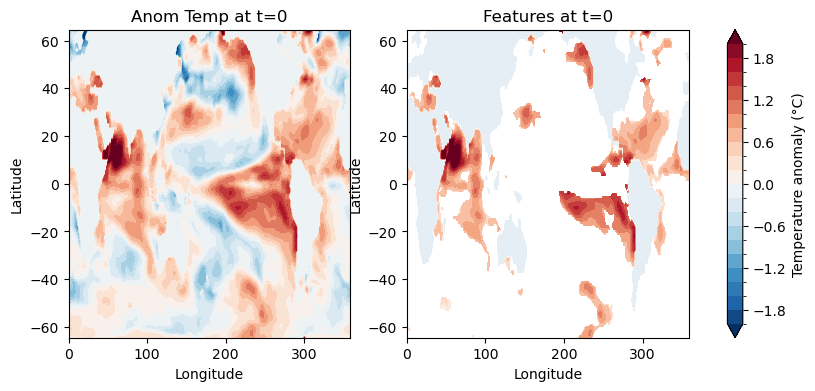

In [28]:
## -------------- Figure of anom temperature and features

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

im1 = anom[30, :, :].plot.contourf(
    ax=ax1,
    levels=21, 
    vmin=-2, 
    vmax=2, 
    cmap='RdBu_r',
    add_colorbar=False
)
ax1.set_title('Anom Temp at t=0', fontsize=12)
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')

im2 = features[30, :, :].plot.contourf(
    ax=ax2,
    levels=21, 
    vmin=-2, 
    vmax=2, 
    cmap='RdBu_r',
    add_colorbar=False
)
ax2.set_title('Features at t=0', fontsize=12)
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')

cbar = plt.colorbar(im1, ax=[ax1, ax2], orientation='vertical', pad=0.05)
cbar.set_label('Temperature anomaly (°C)', fontsize=10)

plt.show()

### 4. Build the ocean mask

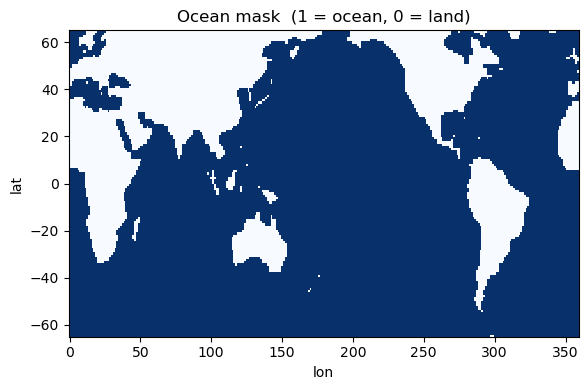

In [35]:
mask = xr.where(da_sst[0,:,:] == 0., 0., 1.)

fig, ax = plt.subplots(figsize=(6, 4))
mask.plot(ax=ax, cmap='Blues', add_colorbar=False)
ax.set_title('Ocean mask  (1 = ocean, 0 = land)')
plt.tight_layout(); plt.show(); plt.close()

### 5. Initialise and run the tracker

| Parameter | Description |
|---|---|
| `radius` | Structuring element radius for morphological close→open. Larger fills wider gaps but risks bridging nearby separate events. |
| `min_size_quartile` | Drop blobs below this percentile of the area distribution. Combined with `min_area_cells` via `max()`. |
| `min_area_cells` | Absolute minimum blob size in grid cells. Always applied regardless of the percentile. |
| `positive` | `True` → track warm anomalies; `False` → cold. |

In [38]:
%%time
tracker = SurfTracker(
    features,
    mask,
    radius            = 2,
    min_size_quartile = 0.25,
    min_area_cells    = 100,
    timedim           = 'time',
    xdim              = 'lon',
    ydim              = 'lat',
    positive          = True,
)
result = tracker.run()
tracker.summary()

Step 1 · morphological cleaning …
    fraction flagged = 0.1022  (OK)
Step 2 · area filtering …
area threshold : 100 cells  (floor=100, percentile=22.0)
Step 3 · 3-D connected-component labelling …
    initial objects : 791
    final objects   : 60
Step 4 · wrapping result …
    final events: 60
SurfTracker — Result Summary
  Input shape    : (40, 138, 288)
  Tracked events : 60
  Duration  min/median/max : 1 / 1 / 22
    >=  1 ts : 60
    >=  3 ts : 20
    >=  6 ts : 11
    >= 12 ts : 5

  Parameters:
    radius               = 2
    min_area_cells       = 100
    min_size_quartile    = 0.25
    positive             = True
CPU times: user 1.01 s, sys: 27.2 ms, total: 1.04 s
Wall time: 1.18 s


### 6. Attributes

In [39]:
print("Attributes:")
for k, v in result.attrs.items():
    print(f"  {k:<30} {v}")

Attributes:
  initial objects identified     791
  final objects tracked          60
  radius                         2
  size quantile threshold        0.25
  min area cells                 100
  min area (effective)           100.0
  percent area reject            0.10522655374881522
  percent area accept            0.8947734462511848


# Run steps separately

In [40]:
tracker2 = SurfTracker(
    features, mask,
    radius=2, min_size_quartile=0.25, min_area_cells=100,
    timedim='time', xdim='lon', ydim='lat',
)

# Step 1 — morphological cleaning + masking
tracker2.clean()
frac = float(tracker2.binary_clean.values.mean())
print(f"Step 1 done — fraction flagged warm: {frac:.4f}")

# Step 2 — area filtering
tracker2.filter()
print(f"Step 2 done — effective area threshold: {tracker2.min_area:.0f} cells")
print(f"             initial objects: {tracker2.N_initial}")

# Step 3 — 3-D connected-component labelling + date-line wrap
tracker2.track()

# Step 4 — package result
tracker2.postprocess()
print(f"Step 4 done — final events: {tracker2.n_events()}")

Step 1 · morphological cleaning …
    fraction flagged = 0.1022  (OK)
Step 1 done — fraction flagged warm: 0.1022
Step 2 · area filtering …
area threshold : 100 cells  (floor=100, percentile=22.0)
Step 2 done — effective area threshold: 100 cells
             initial objects: 791
Step 3 · 3-D connected-component labelling …
    initial objects : 791
    final objects   : 60
Step 4 · wrapping result …
    final events: 60
Step 4 done — final events: 60


### 8. Plotting and Inspection

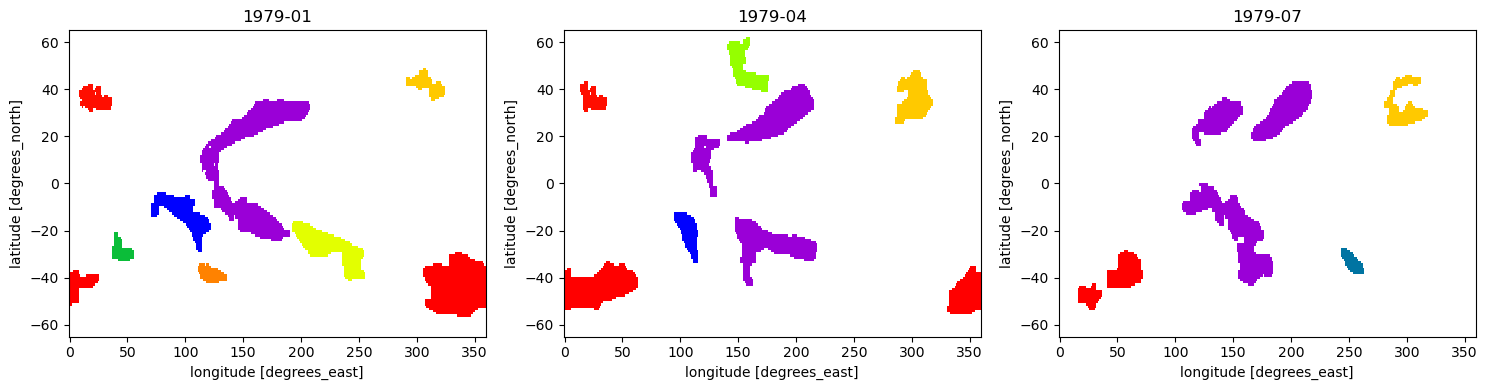

In [41]:
def plot_surface_labels(result, timesteps, cmap='prism'):
    vmax = int(np.nanmax(result.values))
    fig, axes = plt.subplots(1, len(timesteps), figsize=(5 * len(timesteps), 4))
    if len(timesteps) == 1:
        axes = [axes]
    for ax, t in zip(axes, timesteps):
        result.isel(time=t).plot(
            ax=ax, cmap=cmap, vmin=1, vmax=vmax, add_colorbar=False
        )
        try:
            t_label = str(result.time.values[t])[:7]
        except Exception:
            t_label = f't={t}'
        ax.set_title(t_label)
    plt.tight_layout(); plt.show(); plt.close()

plot_surface_labels(result, timesteps=list(range(0, min(9, result.shape[0]), 3)))

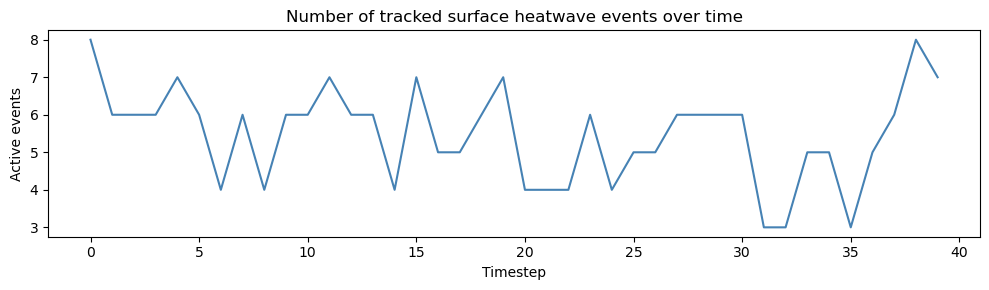

In [42]:
n_per_t = [
    len(np.unique(result.isel(time=t).values[
        ~np.isnan(result.isel(time=t).values)
    ]))
    for t in range(result.shape[0])
]

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(n_per_t, lw=1.5, color='steelblue')
ax.set_xlabel('Timestep'); ax.set_ylabel('Active events')
ax.set_title('Number of tracked surface heatwave events over time')
plt.tight_layout(); plt.show(); plt.close()

Total events        : 60
Duration min/median/max : 1 / 1 / 22
  1 ts  : 30
  2 ts  : 10
  >= 3  : 20


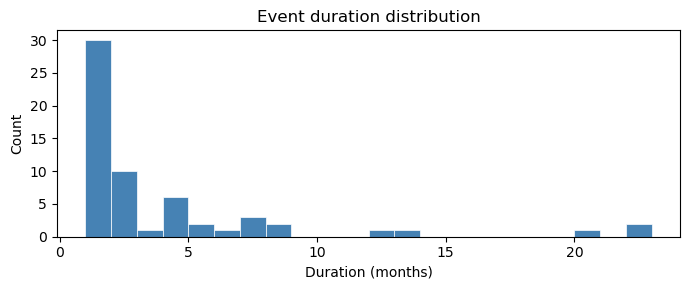

In [43]:
durations = tracker.event_duration()
durs      = np.array(list(durations.values()))

print(f"Total events        : {len(durs)}")
print(f"Duration min/median/max : "
      f"{durs.min()} / {int(np.median(durs))} / {durs.max()}")
print(f"  1 ts  : {(durs == 1).sum()}")
print(f"  2 ts  : {(durs == 2).sum()}")
print(f"  >= 3  : {(durs >= 3).sum()}")

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(durs, bins=range(1, durs.max() + 2), edgecolor='white', linewidth=0.5,
        color='steelblue')
ax.set_xlabel('Duration (months)'); ax.set_ylabel('Count')
ax.set_title('Event duration distribution')
plt.tight_layout(); plt.show(); plt.close()